# Burst Experiment — Learning Rate Sweep

Same 3-phase pipeline as `burst_simple`, but sweeps **learning rate** at a
fixed burst concentration. Use this to find the LR sweet spot where burst
knowledge is acquired fastest yet retained longest.

In [18]:
import sys, os
os.chdir("/workspace/compositional_capabilities_burst")
sys.path.insert(0, ".")
from simple import make_data, pretrain, finetune, forget, report, interp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
%matplotlib inline

OUT = "data/lr_sweep"
SEED = 42

## 1. Generate Data & Pretrain

In [19]:
data = make_data(depth=3, burst_pos=3, n_a=4, n_burst_fns=2, seed=SEED)
print(f"Vocab: {data['vocab_size']}, Context: {data['context_size']}, Prompt: {data['prompt_len']}")
print(f"Other tasks: {data['task_info']['n_other_tasks']}, Burst tasks: {data['task_info']['n_burst_tasks']}")
print(f"Burst functions: {[f'F{b}' for b in data['b_stars']]}")

Vocab: 38, Context: 37, Prompt: 12
Other tasks: 64, Burst tasks: 32
Burst functions: ['F13', 'F14']


In [20]:

import numpy as np
N_samples = 5
_tok = {v: k for k, v in data["token_idx"].items()}
_b_star_set = set(data["b_stars"])

def _decode(seq):
    """Decode a token-index sequence to a human-readable string."""
    parts = []
    for t in seq:
        s = _tok.get(int(t), f"?{t}")
        parts.append("·" if s == " " else ("<P>" if s == "<PAD>" else s))
    return " ".join(parts)

prompt_len = data["prompt_len"]
print(f"Document structure:  S  [functions]  ·  [input]  ·  [out1]  ·  [out2] ...")
print(f"Prompt / target split at token {prompt_len}  "
      f"(model sees prompt, predicts target)")
print(f"Burst functions: {[f'F{b}' for b in data['b_stars']]}\n")

print("── 5 Background (pretraining) examples ─────────────────────────────")
bg_tasks = list(data["bg_pool"].keys())
#choose 5 random sample idx
sample_idx = np.random.choice(len(bg_tasks), size=5, replace=False)

for i in range(5):
    task = bg_tasks[sample_idx[i]]
    seq = data["bg_pool"][task][0]
    prompt = _decode(seq[:prompt_len])
    target = _decode(seq[prompt_len:])
    fns = "  ".join(f"F{f}" for f in task[1:])
    print(f"  [{i+1}]  functions: {fns}")
    print(f"        prompt : {prompt}")
    print(f"        target : {target}")
    print()

print("── 5 Burst (finetuning) examples ────────────────────────────────────")
bt_tasks = list(data["target_pool"].keys())
sample_idx = np.random.choice(len(bt_tasks), size=5, replace=False)
for i in range(5):
    task = bt_tasks[sample_idx[i]]
    seq = data["target_pool"][task][0]
    prompt = _decode(seq[:prompt_len])
    target = _decode(seq[prompt_len:])
    fns = "  ".join(f"F{f}" for f in task[1:])
    burst_here = ", ".join(f"F{f}" for f in task[1:] if f in _b_star_set)
    print(f"  [{i+1}]  functions: {fns}  ← burst: {burst_here}")
    print(f"        prompt : {prompt}")
    print(f"        target : {target}")
    print()

Document structure:  S  [functions]  ·  [input]  ·  [out1]  ·  [out2] ...
Prompt / target split at token 12  (model sees prompt, predicts target)
Burst functions: ['F13', 'F14']

── 5 Background (pretraining) examples ─────────────────────────────
  [1]  functions: F2  F8  F10
        prompt : S F2 F8 F10 · X8 X8 X1 X1 X8 X0 ·
        target : X9 X9 X2 X2 X9 X4 · X6 X6 X1 X1 X6 X0 · X7 X7 X1 X1 X7 X0

  [2]  functions: F1  F7  F12
        prompt : S F1 F7 F12 · X6 X4 X5 X0 X6 X5 ·
        target : X9 X3 X7 X1 X9 X7 · X9 X6 X1 X5 X9 X1 · X6 X9 X1 X2 X6 X1

  [3]  functions: F1  F5  F10
        prompt : S F1 F5 F10 · X8 X4 X1 X3 X2 X3 ·
        target : X9 X6 X2 X0 X7 X0 · X9 X6 X4 X1 X3 X1 · X6 X9 X7 X1 X0 X1

  [4]  functions: F4  F5  F10
        prompt : S F4 F5 F10 · X0 X1 X0 X9 X9 X3 ·
        target : X4 X2 X4 X1 X1 X0 · X0 X4 X0 X5 X5 X1 · X1 X8 X1 X0 X0 X7

  [5]  functions: F3  F7  F12
        prompt : S F3 F7 F12 · X9 X7 X0 X2 X0 X1 ·
        target : X0 X6 X1 X2 X1 X5 · X0 X4 

Pretrain: 0it [00:00, ?it/s]


Converged at step 850 (eval loss plateaued for 5 checks)
Pretrain done: peak acc_other=1.0000, final loss_other=0.5839


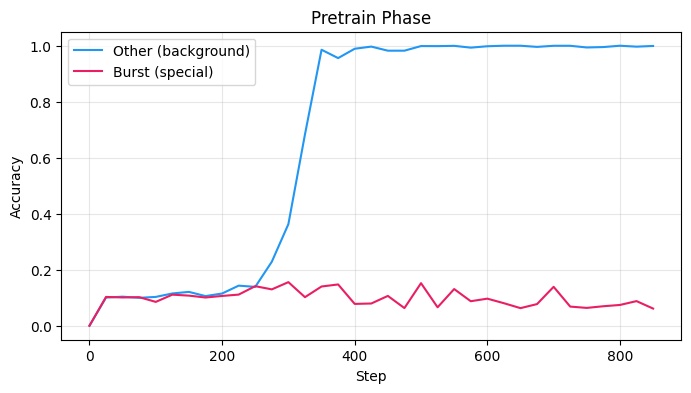

Checkpoint: data/lr_sweep/pretrain/pretrain_ckpt.pt


In [21]:
pt = pretrain(data, f"{OUT}/pretrain", seed=SEED, lr=1e-3)
report.plot_pretrain(pt)
plt.show()
print(f"Checkpoint: {pt['ckpt_path']}")

In [22]:
from simple.model import load_model
from simple.interp import compute_fisher_eigenvectors

_net_pt = load_model(pt["ckpt_path"], data["vocab_size"], data["context_size"])
fisher_eigvecs = compute_fisher_eigenvectors(
    _net_pt, data, k=5, n_power_iters=10, n_batches=16, batch_size=64, seed=SEED,
)
del _net_pt
print(f"Global Fisher eigvecs: {fisher_eigvecs['global_eigvecs'].shape}")
print(f"Top eigenvalues      : {fisher_eigvecs['global_eigvals'].round(4)}")

Global Fisher eigvecs: (1047360, 5)
Top eigenvalues      : [0.0555 0.0074 0.0025 0.0015 0.001 ]


## 2. Finetune — sweep over learning rates

Fixed `BURST_FRAC`, varying `LR`. Each run starts from the same pretrained checkpoint.

In [23]:
import torch.multiprocessing as mp
from simple.finetune import _finetune_worker

BURST_FRAC = 1.0         # fixed concentration for this sweep
STEPS = 500
EVAL_EVERY = 5

LRS = [1e-5, 6e-6, 3e-6]  # sweep these

jobs = [dict(data=data, pretrain_ckpt=pt["ckpt_path"], out_dir=f"{OUT}/finetune",
             burst_frac=BURST_FRAC, steps=STEPS, seed=SEED, quiet=True,
             lr=lr, eval_every=EVAL_EVERY, fisher_eigvecs=fisher_eigvecs, grad_clip=1.0,
             tag=f"lr_{lr:.0e}")
        for lr in LRS]

ctx = mp.get_context("spawn")
with ctx.Pool(len(LRS)) as pool:
    ft_results = pool.map(_finetune_worker, jobs)

# attach the actual LR to each result for easy access later
for r, lr in zip(ft_results, LRS):
    r["lr"] = lr

for r in ft_results:
    print(f"  {r['tag']}: peak_burst={r['peak_burst']:.3f}")

  lr_1e-05: peak_burst=0.354
  lr_6e-06: peak_burst=0.289
  lr_3e-06: peak_burst=0.205


## 3. Forget — measure reversion for each LR

In [24]:
from simple.forget import _forget_worker

FORGET_STEPS = 200
FORGET_LR = 1e-4  # fixed LR for forget phase (independent of finetune LR)

jobs = [dict(data=data, finetune_ckpt=ft["ckpt_path"], out_dir=f"{OUT}/forget",
             pretrain_ckpt=pt["ckpt_path"], steps=FORGET_STEPS, seed=SEED, grad_clip=0.0,
             quiet=True, lr=FORGET_LR)
        for ft in ft_results]

with ctx.Pool(len(ft_results)) as pool:
    fg_results = pool.map(_forget_worker, jobs)

for r, ft in zip(fg_results, ft_results):
    r["lr"] = ft["lr"]

for r in fg_results:
    print(f"  {r['tag']}: peak={r['peak_burst']:.3f} -> end={r['end_burst_acc']:.3f} "
          f"(drop {r['dropoff_pct']:.1f}%)")

  lr_1e-05: peak=0.354 -> end=0.108 (drop 69.6%)
  lr_6e-06: peak=0.287 -> end=0.091 (drop 68.5%)
  lr_3e-06: peak=0.205 -> end=0.081 (drop 60.2%)


## 4. Plots

Custom coloring by LR (log scale: warm = high LR, cool = low LR).

In [25]:
# ── colour helper: log-scale LR → colour ─────────────────────────────────
log_lrs = np.log10([r["lr"] for r in ft_results])
norm = mcolors.Normalize(vmin=log_lrs.min(), vmax=log_lrs.max())
cmap = plt.cm.coolwarm_r  # red = high LR, blue = low LR

def lr_color(lr):
    return cmap(norm(np.log10(lr)))

def offset_fg_steps(ft_log, fg_log):
    ft_end = ft_log["step"][-1] if ft_log["step"] else 0
    return [s + ft_end for s in fg_log["step"]]

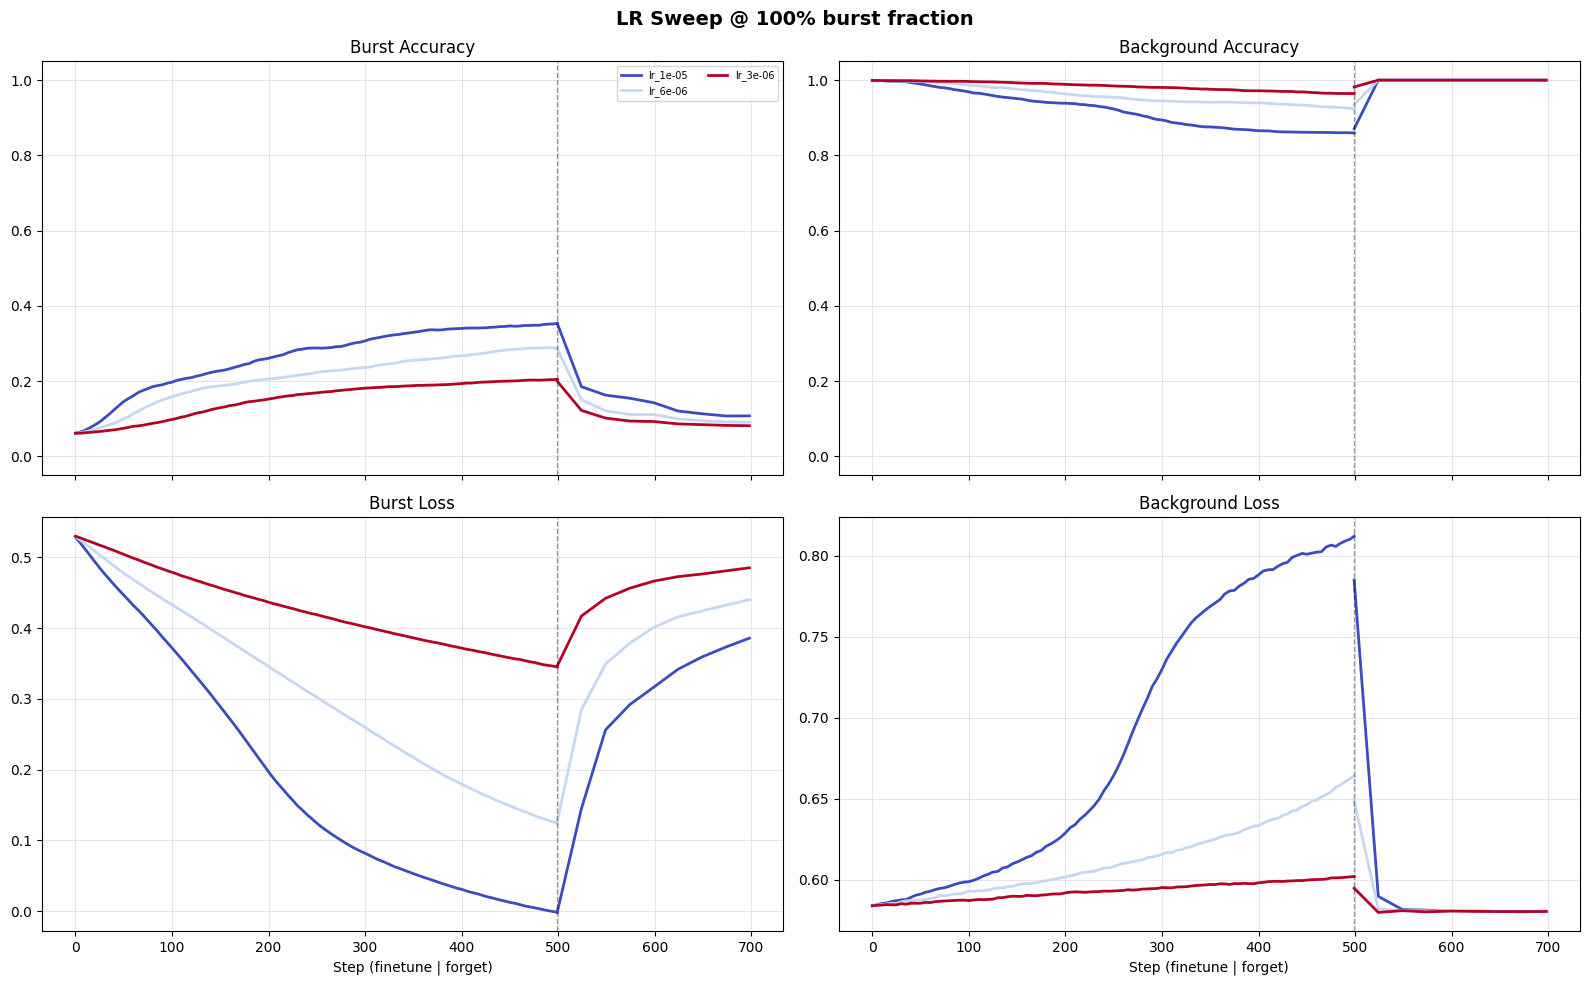

In [26]:
# ── Accuracy & Loss: finetune → forget ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex="col")

for ft, fg in zip(ft_results, fg_results):
    c = lr_color(ft["lr"])
    lab = ft["tag"]
    fl, gl = ft["log"], fg["log"]
    fg_steps = offset_fg_steps(fl, gl)

    axes[0, 0].plot(fl["step"], fl["acc_burst"], color=c, lw=2, label=lab)
    axes[0, 0].plot(fg_steps, gl["acc_burst"], color=c, lw=2)

    axes[0, 1].plot(fl["step"], fl["acc_other"], color=c, lw=2, label=lab)
    axes[0, 1].plot(fg_steps, gl["acc_other"], color=c, lw=2)

    axes[1, 0].plot(fl["step"], np.log10(fl["loss_burst"]), color=c, lw=2, label=lab)
    axes[1, 0].plot(fg_steps, np.log10(gl["loss_burst"]), color=c, lw=2)

    axes[1, 1].plot(fl["step"], fl["loss_other"], color=c, lw=2, label=lab)
    axes[1, 1].plot(fg_steps, gl["loss_other"], color=c, lw=2)

boundary = ft_results[0]["log"]["step"][-1]
for ax in axes.flat:
    ax.axvline(boundary, color="black", ls="--", lw=1, alpha=0.4)
    ax.grid(True, alpha=0.3)

axes[0, 0].set_title("Burst Accuracy"); axes[0, 0].set_ylim(-0.05, 1.05)
axes[0, 1].set_title("Background Accuracy"); axes[0, 1].set_ylim(-0.05, 1.05)
axes[1, 0].set_title("Burst Loss"); axes[1, 1].set_title("Background Loss")
axes[1, 0].set_xlabel("Step (finetune | forget)")
axes[1, 1].set_xlabel("Step (finetune | forget)")
axes[0, 0].legend(fontsize=7, ncol=2)
fig.suptitle(f"LR Sweep @ {BURST_FRAC:.0%} burst fraction", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

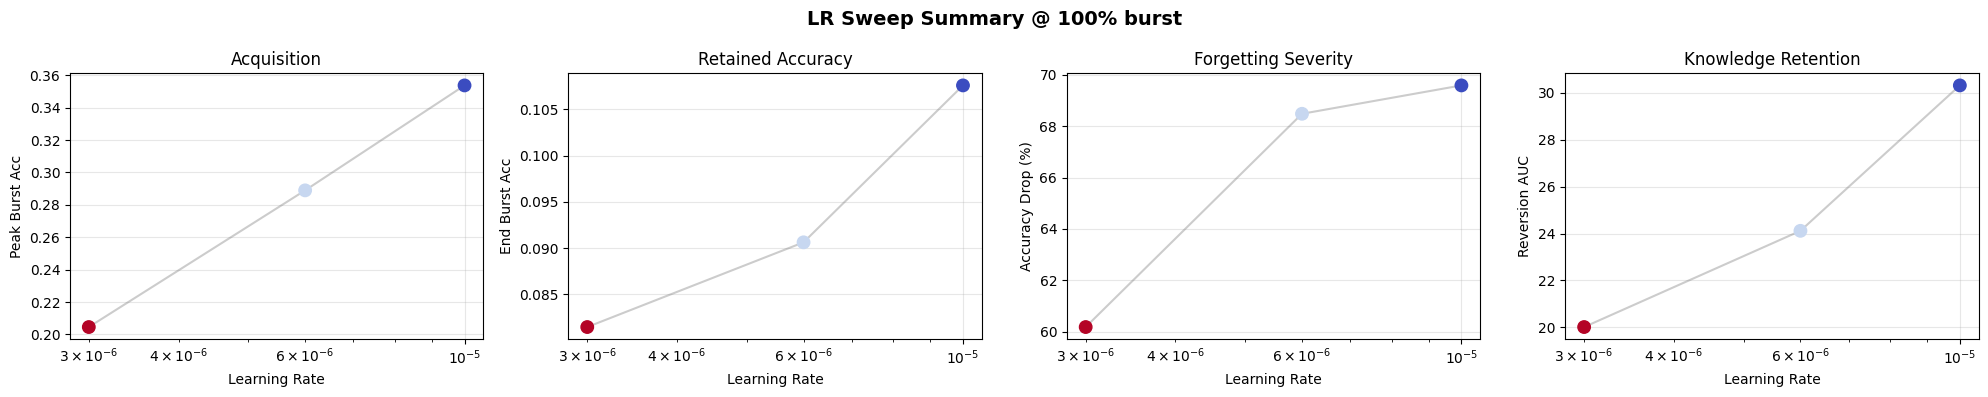

In [27]:
# ── Summary scatter: LR vs key metrics ────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

lrs = [r["lr"] for r in ft_results]
colors = [lr_color(lr) for lr in lrs]
peaks = [r["peak_burst"] for r in ft_results]
drops = [r["dropoff_pct"] for r in fg_results]
aucs = [r["reversion_auc"] for r in fg_results]
ends = [r["end_burst_acc"] for r in fg_results]

for ax, vals, ylabel, title in [
    (axes[0], peaks, "Peak Burst Acc", "Acquisition"),
    (axes[1], ends, "End Burst Acc", "Retained Accuracy"),
    (axes[2], drops, "Accuracy Drop (%)", "Forgetting Severity"),
    (axes[3], aucs, "Reversion AUC", "Knowledge Retention"),
]:
    ax.scatter(lrs, vals, c=colors, s=80, zorder=3)
    ax.plot(lrs, vals, color="gray", alpha=0.4, zorder=2)
    ax.set_xscale("log")
    ax.set_xlabel("Learning Rate")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

fig.suptitle(f"LR Sweep Summary @ {BURST_FRAC:.0%} burst", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

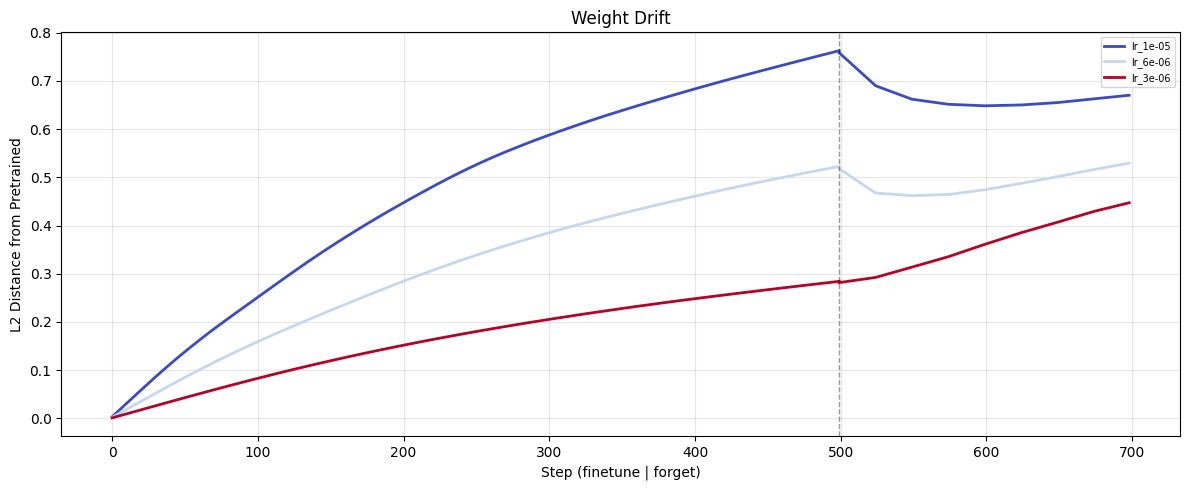

In [28]:
# ── Weight drift ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
for ft, fg in zip(ft_results, fg_results):
    c = lr_color(ft["lr"])
    fl, gl = ft["log"], fg["log"]
    ax.plot(fl["step"], fl["weight_drift"], color=c, lw=2, label=ft["tag"])
    if "weight_drift_from_pt" in gl and gl["weight_drift_from_pt"]:
        ax.plot(offset_fg_steps(fl, gl), gl["weight_drift_from_pt"], color=c, lw=2)

ax.axvline(ft_results[0]["log"]["step"][-1], color="black", ls="--", lw=1, alpha=0.4)
ax.set_xlabel("Step (finetune | forget)"); ax.set_ylabel("L2 Distance from Pretrained")
ax.set_title("Weight Drift"); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
fig.tight_layout(); plt.show()

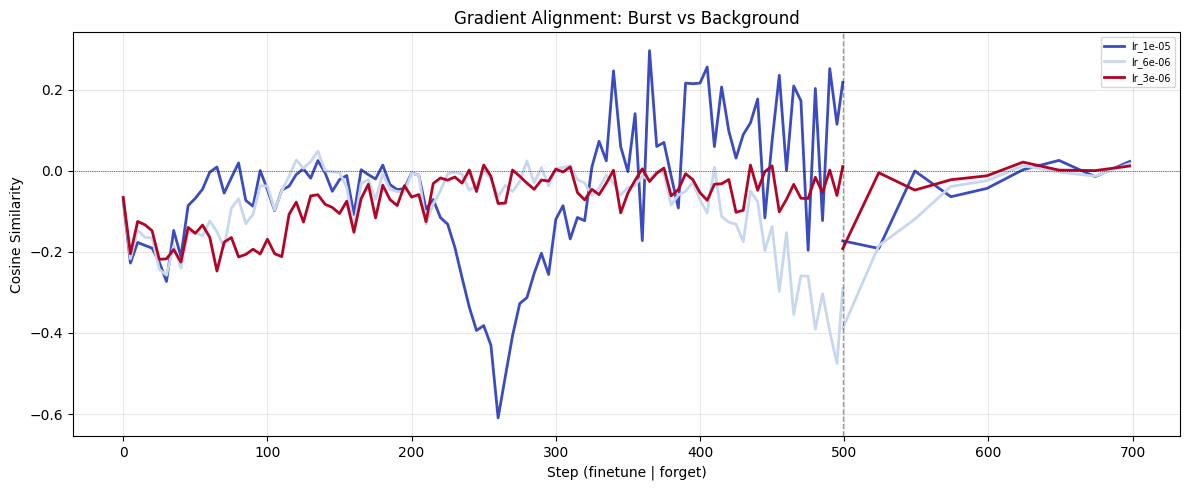

In [29]:
# ── Gradient cosine (burst vs bg) ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
for ft, fg in zip(ft_results, fg_results):
    c = lr_color(ft["lr"])
    fl, gl = ft["log"], fg["log"]
    ax.plot(fl["step"], fl["grad_cosine_burst_bg"], color=c, lw=2, label=ft["tag"])
    if "grad_cosine_burst_bg" in gl and gl["grad_cosine_burst_bg"]:
        ax.plot(offset_fg_steps(fl, gl), gl["grad_cosine_burst_bg"], color=c, lw=2)

ax.axvline(ft_results[0]["log"]["step"][-1], color="black", ls="--", lw=1, alpha=0.4)
ax.axhline(0, color="black", lw=0.5, ls=":")
ax.set_xlabel("Step (finetune | forget)"); ax.set_ylabel("Cosine Similarity")
ax.set_title("Gradient Alignment: Burst vs Background")
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
fig.tight_layout(); plt.show()

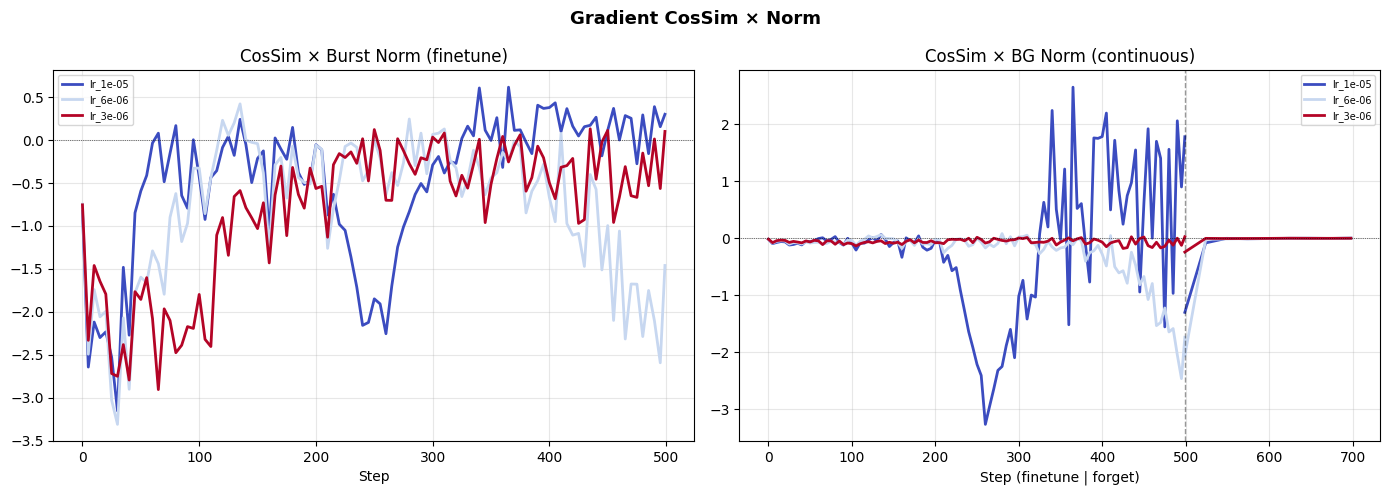

In [30]:
# ── Gradient CosSim × Norm ────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for ft, fg in zip(ft_results, fg_results):
    c = lr_color(ft["lr"])
    fl, gl = ft["log"], fg["log"]
    if "grad_cossim_x_norm_burst" in fl:
        ax1.plot(fl["step"], fl["grad_cossim_x_norm_burst"], color=c, lw=2, label=ft["tag"])
    if "grad_cossim_x_norm_bg" in fl:
        ax2.plot(fl["step"], fl["grad_cossim_x_norm_bg"], color=c, lw=2, label=ft["tag"])
    if "grad_cossim_x_norm" in gl and gl["grad_cossim_x_norm"]:
        ax2.plot(offset_fg_steps(fl, gl), gl["grad_cossim_x_norm"], color=c, lw=2)

boundary = ft_results[0]["log"]["step"][-1]
for ax in [ax1, ax2]:
    ax.axhline(0, color="black", lw=0.5, ls=":")
    ax.grid(True, alpha=0.3)
ax2.axvline(boundary, color="black", ls="--", lw=1, alpha=0.4)
ax1.set_title("CosSim × Burst Norm (finetune)"); ax1.set_xlabel("Step")
ax2.set_title("CosSim × BG Norm (continuous)"); ax2.set_xlabel("Step (finetune | forget)")
ax1.legend(fontsize=7); ax2.legend(fontsize=7)
fig.suptitle("Gradient CosSim × Norm", fontsize=13, fontweight="bold")
fig.tight_layout(); plt.show()

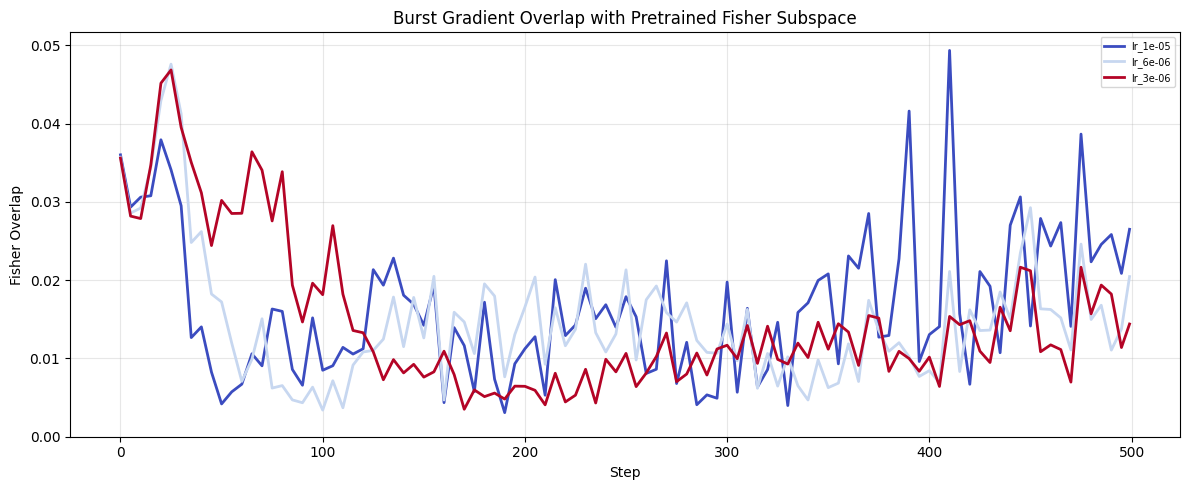

In [31]:
# ── Fisher overlap ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
for ft in ft_results:
    fl = ft["log"]
    if "fisher_overlap" in fl and fl["fisher_overlap"]:
        ax.plot(fl["step"], fl["fisher_overlap"], color=lr_color(ft["lr"]),
                lw=2, label=ft["tag"])

ax.set_xlabel("Step"); ax.set_ylabel("Fisher Overlap")
ax.set_title("Burst Gradient Overlap with Pretrained Fisher Subspace")
ax.set_ylim(bottom=0); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
fig.tight_layout(); plt.show()

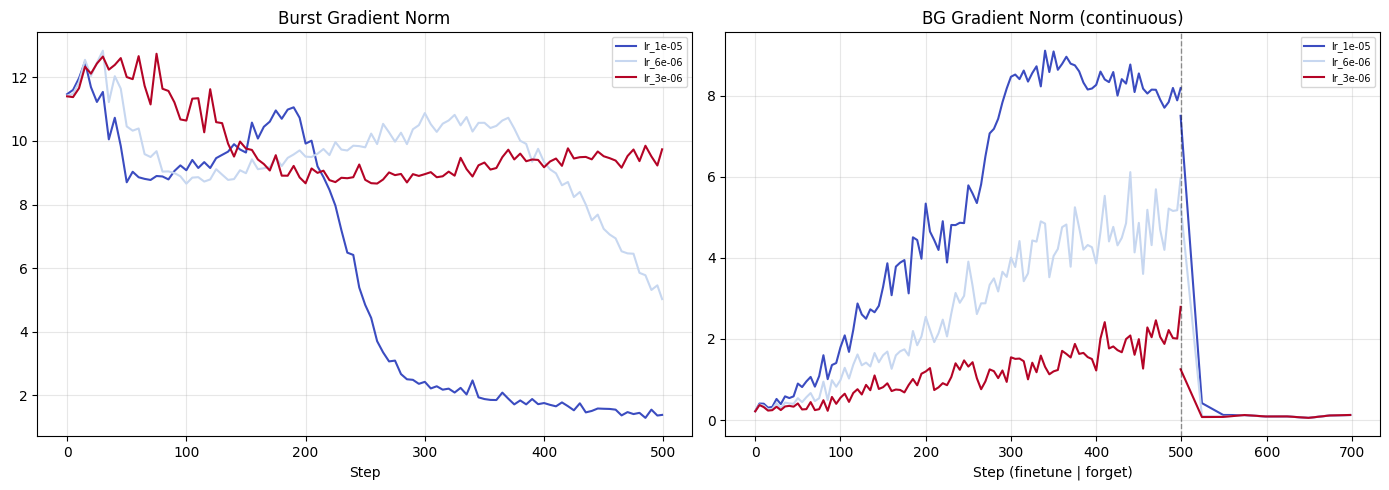

In [32]:
# ── Gradient norms ────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for ft, fg in zip(ft_results, fg_results):
    c = lr_color(ft["lr"])
    fl, gl = ft["log"], fg["log"]
    if "grad_norm_burst" in fl:
        ax1.plot(fl["step"], fl["grad_norm_burst"], color=c, lw=1.5, label=ft["tag"])
    if "grad_norm_bg" in fl:
        ax2.plot(fl["step"], fl["grad_norm_bg"], color=c, lw=1.5, label=ft["tag"])
    if "grad_norm" in gl and gl["grad_norm"]:
        ax2.plot(offset_fg_steps(fl, gl), gl["grad_norm"], color=c, lw=1.5)

ax2.axvline(ft_results[0]["log"]["step"][-1], color="black", ls="--", lw=1, alpha=0.4)
ax1.set_title("Burst Gradient Norm"); ax1.set_xlabel("Step")
ax2.set_title("BG Gradient Norm (continuous)"); ax2.set_xlabel("Step (finetune | forget)")
for ax in [ax1, ax2]:
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
fig.tight_layout(); plt.show()

## 5. Summary Table

In [33]:
rows = report.summary_table(ft_results, fg_results)

Tag             Burst%   Peak    End  Drop%      AUC 95%-life 80%-life
----------------------------------------------------------------------
lr_1e-05          100%  0.354  0.108   69.6       30   25.000   25.000
lr_6e-06          100%  0.289  0.091   68.5       24   25.000   25.000
lr_3e-06          100%  0.205  0.081   60.2       20   25.000   25.000


## 6. Save Report

In [34]:
report.save_report(pt, ft_results, fg_results, f"{OUT}/report")

Report saved to data/lr_sweep/report
